# Mini-Project: Speech Emotion Classification
## Prashanth Kannadaguli
### Senior Data Science Trainer

## Problem Statement

Build a model to recognize emotion from speech using Ensemble learning

## Learning Objectives

At the end of the mini-project, you will be able to :

* extract the features from audio data
* implement ML classification algorithms individually and as Ensembles, to classify emotions
* record the voice sample and test it with trained model

## Dataset

**TESS Dataset**

The first dataset chosen for this mini-project is the [TESS](https://dataverse.scholarsportal.info/dataset.xhtml?persistentId=doi:10.5683/SP2/E8H2MF) (Toronto emotional speech set) dataset. It contains 2880 files.  A set of 200 target words were spoken in the carrier phrase "Say the word _____' by two actresses and the sets were recorded in seven different emotions (anger, disgust, fear, happiness, pleasant surprise, sadness, and neutral). Both actresses spoke English as their first language, were university educated, and had musical training. Audiometric testing indicated that both actresses had thresholds within the normal range.

**Ravdess Dataset**

The second dataset chosen for this mini-project is [Ravdess](https://zenodo.org/record/1188976#.YLczy4XivIU) (The Ryerson Audio-Visual Database of Emotional Speech and Song). This dataset contains 1440 files: 60 trials per actor x 24 actors = 1440. The RAVDESS contains 24 professional actors (12 female, 12 male), vocalizing two lexically-matched statements in a neutral North American accent. Speech emotions includes calm, happy, sad, angry, fearful, surprise, and disgust expressions. Each expression is produced at two levels of emotional intensity (normal, strong), with an additional neutral expression.

**File naming convention**

Each of the 1440 files has a unique filename. The filename consists of a 7-part numerical identifier (e.g., 03-01-06-01-02-01-12.wav). These identifiers define the stimulus characteristics:

**Filename identifiers**

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Filename example: `03-01-06-01-02-01-12.wav`

    - Audio-only - 03
    - Speech - 01
    - Fearful - 06
    - Normal intensity - 01
    - Statement "dogs" - 02
    - 1st Repetition - 01
    - 12th Actor - 12 Female, as the actor ID number is even.

## Information

**Speech Emotion Recognition (SER)** is the task of recognizing the emotion from  speech, irrespective of the semantics. Humans can efficiently perform this task as a natural part of speech communication, however, the ability to conduct it automatically using programmable devices is a field of active research.

Studies of automatic emotion recognition systems aim to create efficient, real-time methods of detecting the emotions of mobile phone users, call center operators and customers, car drivers, pilots, and many other human-machine communication users. Adding emotions to machines forms an important aspect of making machines appear and act in a human-like manner

Lets gain familiarity with some of the audio based features that are commonly used for SER.

**Mel scale** — The mel scale (derived from the word *melody*) is a perceptual scale of pitches judged by listeners to be equal in distance from one another. The reference point between this scale and normal frequency measurement is defined by assigning a perceptual pitch of 1000 mels to a 1000 Hz tone, 40 dB above the listener's threshold. Above about 500 Hz, increasingly large intervals are judged by listeners to produce equal pitch increments. Refer [here](https://towardsdatascience.com/learning-from-audio-the-mel-scale-mel-spectrograms-and-mel-frequency-cepstral-coefficients-f5752b6324a8) for more detailed information.

**Pitch** — how high or low a sound is. It depends on frequency, higher pitch is high frequency

**Frequency** — speed of vibration of sound, measures wave cycles per second

**Chroma** — Representation for audio where spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma). Computed by summing the log frequency magnitude spectrum across octaves.

**Fourier Transforms** — used to convert from time domain to frequency domain. Time domain shows how signal changes over time. Frequency domain shows how much of the signal lies within each given frequency band over a range of frequencies

**Librosa**

[Librosa](https://librosa.org/doc/latest/index.html) is a Python package, built for speech and audio analytics. It provides modular functions that simplify working with audio data and help in achieving a wide range of applications such as identification of the personal characteristics of different individuals' voice samples, detecting emotions from audio samples etc.

For further details on the Librosa package, refer [here](https://conference.scipy.org/proceedings/scipy2015/pdfs/brian_mcfee.pdf).


### Import Neccesary Packages

In [17]:
# Import the required libraries for audio processing, data handling, visualization, and machine learning.
from pathlib import Path
import os
import zipfile
import requests
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import tqdm as notebook_tqdm

from IPython.display import Audio, display

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier



# The notebook uses librosa for audio processing.
# soundfile is used by librosa to read WAV files.
import soundfile as sf
print(f'librosa version: {librosa.__version__}')
print(f'soundfile version: {sf.__version__}')


librosa version: 1.0.0
soundfile version: 0.14.0


### Download and unzip dataset from https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Ravdess_Tess.zip

In [18]:
dataset_dir = Path('Tess')

zip_url = "https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Ravdess_Tess.zip"
zip_path = Path("Ravdess_Tess.zip")

# Only download and unzip if the folder doesn't already exist
if not dataset_dir.exists():
    print("Dataset folder not found. Downloading dataset...")
    
    # Download the file
    response = requests.get(zip_url, stream=True)
    with open(zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                
    print("Download complete. Unzipping dataset...")
    
    # Unzip the file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
        
    print("Extraction completed successfully.")
else:
    print(f"Dataset already exists locally at: {dataset_dir.resolve()}")

Dataset already exists locally at: /home/arshadruk/Programs/Mini Projects/Project3/Tess


### Work-Flow

* Load the TESS audio data and extract features and labels

* Load the Ravdess audio data and extract features

* Combine both the audio dataset features

* Train and test the model with TESS + Ravdess Data

* Record the team audio samples and add them to TESS + Ravdess data

* Train and test the model with TESS + Ravdess + Team Recorded (combined) data

* Test each of the models with live audio sample recording.

### Load the Tess data and Ravdess data audio files

Hint: `glob.glob`

In [19]:
# Search the ENTIRE current directory for any WAV files
all_audio_files = [str(p) for p in Path('.').rglob('*') if p.suffix.lower() == '.wav']

# Separate the two datasets based on their folder names cleanly
tess_files = [f for f in all_audio_files if 'Tess' in Path(f).parts]
ravdess_files = [f for f in all_audio_files if 'ravdess' in Path(f).parts or 'Ravdess' in Path(f).parts]

print(f'TESS audio files: {len(tess_files)}')
print(f'RAVDESS audio files: {len(ravdess_files)}')
print(f'Total audio files: {len(all_audio_files)}')

TESS audio files: 2679
RAVDESS audio files: 1168
Total audio files: 3847


#### Play the sample audio

In [20]:
# Play one sample audio file from the combined dataset.
sample_audio = all_audio_files[0]
print(f'Sample file: {sample_audio}')
display(Audio(filename=sample_audio))


Sample file: Tess/OAF_Fear/OAF_back_fear.wav


### Data Exploration and Visualization

#### Visualize the distribution of all the labels

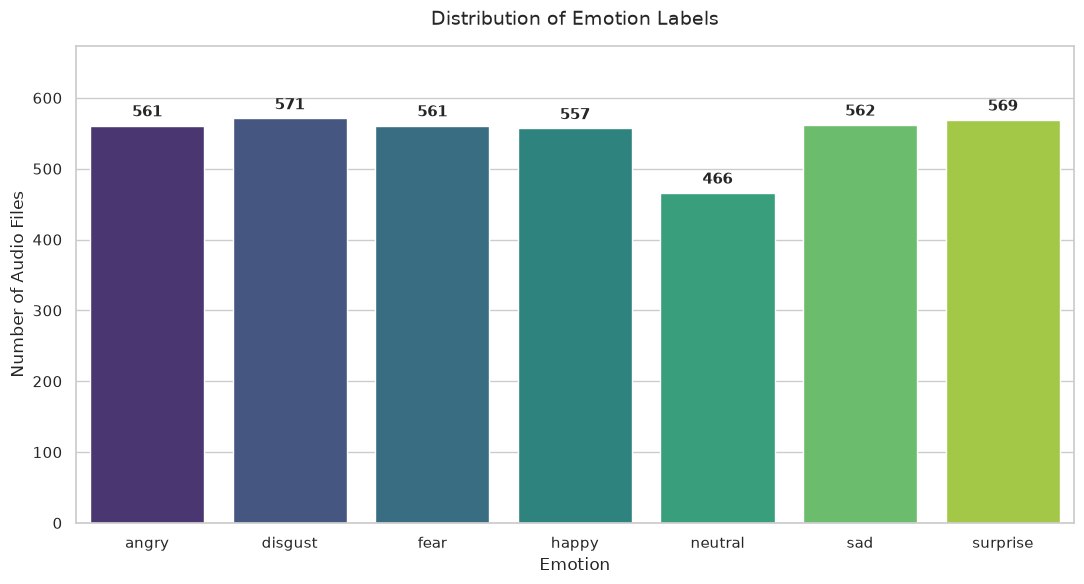

In [21]:
# Define the missing helper function first
def get_emotion_from_path(file_path):
    normalized_path = file_path.replace('\\', '/')
    file_name = os.path.basename(normalized_path)
    
    ravdess_map = {
        '01': 'neutral', '02': 'calm', '03': 'happy',
        '04': 'sad', '05': 'angry', '06': 'fear',
        '07': 'disgust', '08': 'surprise'
    }
    
    parts = file_name.split('-')
    if len(parts) >= 3 and parts[0] in ['01', '02', '03']:
        emotion_code = parts[2]
        return ravdess_map.get(emotion_code, None)
    
    file_lower = file_name.lower()
    if 'angry' in file_lower or 'anger' in file_lower: return 'angry'
    elif 'disgust' in file_lower: return 'disgust'
    elif 'fear' in file_lower: return 'fear'
    elif 'happy' in file_lower or 'happiness' in file_lower: return 'happy'
    elif 'neutral' in file_lower: return 'neutral'
    elif 'sad' in file_lower or 'sadness' in file_lower: return 'sad'
    elif '_ps' in file_lower or 'pleasant' in file_lower or 'surprise' in file_lower: return 'surprise'
    elif 'calm' in file_lower: return 'calm'
    
    return None

# 1. Map audio files to emotions using a DataFrame for safety
df = pd.DataFrame({"file_path": all_audio_files})
df["emotion"] = df["file_path"].apply(get_emotion_from_path)

# 2. Filter out unmatched files without breaking file-to-label alignment
df_clean = df.dropna(subset=["emotion"]).copy()

# 3. Compute count per label and sort alphabetically
label_counts = df_clean["emotion"].value_counts().sort_index()

# 4. Plot distribution with Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    palette="viridis",
    hue=label_counts.index,
    legend=False,
)

# 5. Fix clipped text by expanding Y-axis headroom and adding count labels
max_count = label_counts.max()
plt.ylim(0, max_count * 1.18)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=11,
            fontweight="bold",
        )

plt.title("Distribution of Emotion Labels", fontsize=14, pad=15)
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Audio Files", fontsize=12)
plt.xticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

#### Visualize sample audio signal using librosa

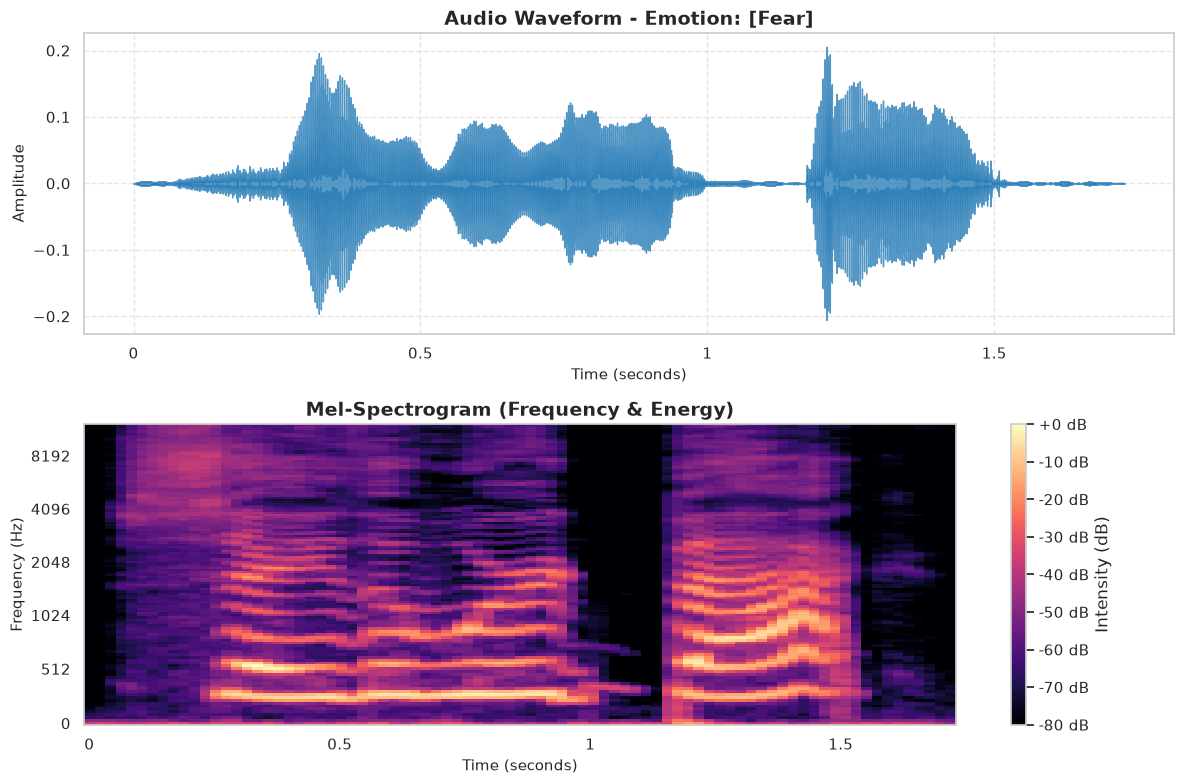

In [22]:
# Load a sample audio signal using librosa
sample_signal, sample_sr = librosa.load(sample_audio, sr=None)
emotion_label = get_emotion_from_path(sample_audio).title()

# Create a figure with two stacked subplots
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

# 1. Plot the Waveform (Time Domain)
librosa.display.waveshow(sample_signal, sr=sample_sr, ax=ax[0], alpha=0.75, color="#1f77b4")
ax[0].set_title(f'Audio Waveform - Emotion: [{emotion_label}]', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Time (seconds)', fontsize=11)
ax[0].set_ylabel('Amplitude', fontsize=11)
ax[0].grid(True, linestyle='--', alpha=0.5)

# 2. Plot the Mel-Spectrogram (Frequency Domain)
# Calculate the Mel-spectrogram and convert power to decibels (dB)
mel_spect = librosa.feature.melspectrogram(y=sample_signal, sr=sample_sr, n_mels=128)
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

# Display the spectrogram
img = librosa.display.specshow(
    mel_spect_db, 
    sr=sample_sr, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax[1], 
    cmap='magma'
)
ax[1].set_title('Mel-Spectrogram (Frequency & Energy)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Time (seconds)', fontsize=11)
ax[1].set_ylabel('Frequency (Hz)', fontsize=11)

# Add a colorbar to interpret the decibel intensity
fig.colorbar(img, ax=ax[1], format='%+2.0f dB', label='Intensity (dB)')

plt.tight_layout()
plt.show()

### Feature extraction

Read one WAV file at a time using `Librosa`. An audio time series in the form of a 1-dimensional array for mono or 2-dimensional array for stereo, along with time sampling rate (which defines the length of the array), where the elements within each of the arrays represent the amplitude of the sound waves is returned by `librosa.load()` function. Refer to the supplementary notebook ('Audio feature extraction')

To know more about Librosa, explore the [link](https://librosa.org/doc/latest/feature.html)

In [23]:
# Extract a compact set of commonly used speech-emotion features from one WAV file.
def extract_features(file_path):
    audio, sample_rate = librosa.load(file_path, sr=None, mono=True)

    # MFCCs capture the spectral characteristics of speech.
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

    # Chroma represents the distribution of energy across the 12 pitch classes.
    chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)

    # Mel-spectrogram represents the signal on the perceptual Mel frequency scale.
    mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=40)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Combine mean and standard deviation so each audio file becomes a fixed-length vector.
    features = np.hstack([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        chroma.mean(axis=1), chroma.std(axis=1),
        mel_db.mean(axis=1), mel_db.std(axis=1)
    ])

    return features

# Test the feature extraction function on one file.
sample_features = extract_features(sample_audio)
print(f'Number of extracted features: {len(sample_features)}')


Number of extracted features: 184


#### Create a dictionary or a function to encode the emotions

In [24]:
# Map all emotion names to integer labels for machine-learning models.
emotion_mapping = {
    'neutral': 0,
    'calm': 1,
    'happy': 2,
    'sad': 3,
    'angry': 4,
    'fear': 5,
    'disgust': 6,
    'surprise': 7
}

# Reverse mapping is useful when displaying predictions and evaluation results.
label_mapping = {v: k for k, v in emotion_mapping.items()}

def encode_emotion(emotion):
    return emotion_mapping[emotion]

print('Emotion mapping:')
print(emotion_mapping)


Emotion mapping:
{'neutral': 0, 'calm': 1, 'happy': 2, 'sad': 3, 'angry': 4, 'fear': 5, 'disgust': 6, 'surprise': 7}


#### TESS data feature extraction

In [25]:
# Extract features from all TESS audio files.
tess_features = []
tess_labels = []

for i, file_path in enumerate(tess_files, start=1):
    try:
        tess_features.append(extract_features(file_path))
        tess_labels.append(encode_emotion(get_emotion_from_path(file_path)))
    except Exception as e:
        print(f'Skipping TESS file {file_path}: {e}')

print(f'TESS feature rows extracted: {len(tess_features)}')


TESS feature rows extracted: 2679


#### Ravdess data feature extraction

In [26]:
# Initialize lists to hold features and labels
ravdess_features = []
ravdess_labels = []

print(f"Starting feature extraction for {len(ravdess_files)} RAVDESS files...")

for i, file_path in enumerate(ravdess_files, start=1):
    try:
        # Extract audio features (MFCC, Chroma, Mel, etc.)
        features = extract_features(file_path)
        
        # Extract and encode the emotion label from the filename
        emotion_str = get_emotion_from_path(file_path)
        encoded_label = encode_emotion(emotion_str)
        
        # Append only if extraction was successful
        if features is not None and encoded_label is not None:
            ravdess_features.append(features)
            ravdess_labels.append(encoded_label)
            
    except Exception as e:
        print(f'Skipping RAVDESS file {file_path}: {e}')
        
    # Print progress every 200 files
    if i % 200 == 0:
        print(f"Processed {i} / {len(ravdess_files)} files...")

# Convert lists to NumPy arrays for compatibility with Scikit-Learn
ravdess_features = np.array(ravdess_features)
ravdess_labels = np.array(ravdess_labels)

print('\n--- RAVDESS Extraction Complete ---')
print(f'RAVDESS feature matrix shape: {ravdess_features.shape}')
print(f'RAVDESS labels array shape: {ravdess_labels.shape}')

Starting feature extraction for 1168 RAVDESS files...
Processed 200 / 1168 files...
Processed 400 / 1168 files...
Processed 600 / 1168 files...
Processed 800 / 1168 files...
Processed 1000 / 1168 files...

--- RAVDESS Extraction Complete ---
RAVDESS feature matrix shape: (1168, 184)
RAVDESS labels array shape: (1168,)


#### Save the features

It is best advised to save the features in dataframe and maintain so that feature extraction step is not required to be performed every time.

* Make a DataFrame with features and labels

* Write dataframe into `.CSV` file and save it offline.

In [27]:
# 1. Combine TESS and RAVDESS features into one array
features = np.vstack([tess_features, ravdess_features])

# 2. Combine labels safely (np.concatenate handles both lists and arrays perfectly)
labels = np.concatenate([tess_labels, ravdess_labels])

# 3. Make a DataFrame with features and labels
feature_columns = [f'feature_{i+1}' for i in range(features.shape[1])]
data = pd.DataFrame(features, columns=feature_columns)
data['label'] = labels

# 4. Write dataframe into .CSV file and save it offline
features_csv = 'tess_ravdess_features.csv'
data.to_csv(features_csv, index=False)

print(f'Feature DataFrame shape: {data.shape}')
# print(f'Features saved to: {Path(features_csv).resolve()}') # uncomment if Path was imported
data.head()

Feature DataFrame shape: (3847, 185)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_176,feature_177,feature_178,feature_179,feature_180,feature_181,feature_182,feature_183,feature_184,label
0,-437.244507,60.606316,4.735497,-8.189329,1.751805,5.401639,-12.745217,-1.665546,-9.431614,0.366829,...,13.998698,14.747164,14.324739,14.799926,14.455912,13.313221,12.659661,11.804099,11.850775,5
1,-437.686432,69.829048,15.912691,-18.658737,-10.559127,7.766725,-12.291351,0.690511,-15.274222,-0.572598,...,12.701782,13.371881,14.136515,14.415262,14.294825,13.459638,12.085957,10.457352,10.810188,5
2,-445.878601,38.594421,12.448332,5.859766,7.332949,3.414988,-13.360972,-1.833906,-12.037913,-0.264681,...,13.676707,14.099975,13.917761,14.242243,14.249765,13.304804,12.870232,12.361378,11.876125,5
3,-408.698486,60.249878,10.387374,-12.225668,-3.497180,5.246920,-11.679508,0.022897,-14.138883,0.512466,...,13.731604,14.480597,14.272789,14.817424,15.070198,13.481722,12.931466,12.716155,12.080855,5
4,-489.933838,50.229908,22.550831,7.463129,9.276794,2.063001,-6.944909,2.026595,-11.649493,-5.645828,...,12.695702,13.540593,13.596532,14.567525,14.141174,13.315003,12.366262,11.375635,11.913603,5


#### Split the data into train and test

In [28]:

# 1. Ensure feature columns are defined (adjust column names to match your dataset)
# If 'label' is your target, exclude it from features:
feature_columns = [col for col in data.columns if col != 'label']

# 2. Separate features and target labels
X = data[feature_columns]
y = data['label']

# 3. Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 4. Display sample counts and class distribution verification
print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

# Check class distribution ratio to confirm stratification worked
print("\nTrain target class distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target class distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training samples: 3077
Testing samples: 770

Train target class distribution (%):
label
6    14.85
7    14.79
5    14.59
3    14.59
4    14.59
2    14.46
0    12.12
Name: proportion, dtype: float64

Test target class distribution (%):
label
6    14.81
7    14.81
3    14.68
4    14.55
5    14.55
2    14.55
0    12.08
Name: proportion, dtype: float64


### Train the model with TESS + Ravdess data

* Apply DecisionTree and find clasification report, confusion matrix, AUC-ROC curve

Classification Report:
              precision    recall  f1-score   support

       angry       0.93      0.83      0.88        93
        fear       0.69      0.61      0.64       112
       happy       0.63      0.75      0.69       113
     neutral       0.87      0.71      0.78       112
         sad       0.87      0.74      0.80       112
    surprise       0.82      0.59      0.68       114
        calm       0.49      0.80      0.61       114

    accuracy                           0.71       770
   macro avg       0.76      0.72      0.73       770
weighted avg       0.75      0.71      0.72       770



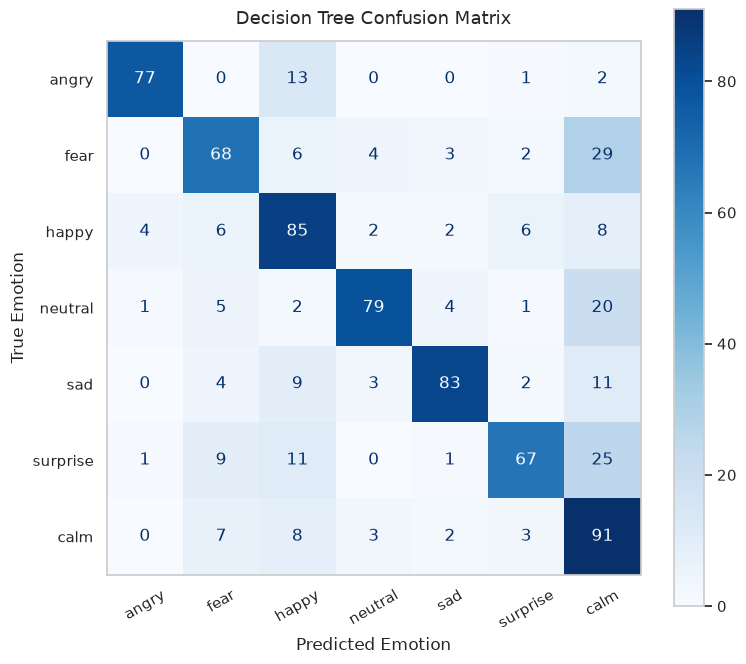

Safe Macro-average ROC-AUC Score: 0.9306



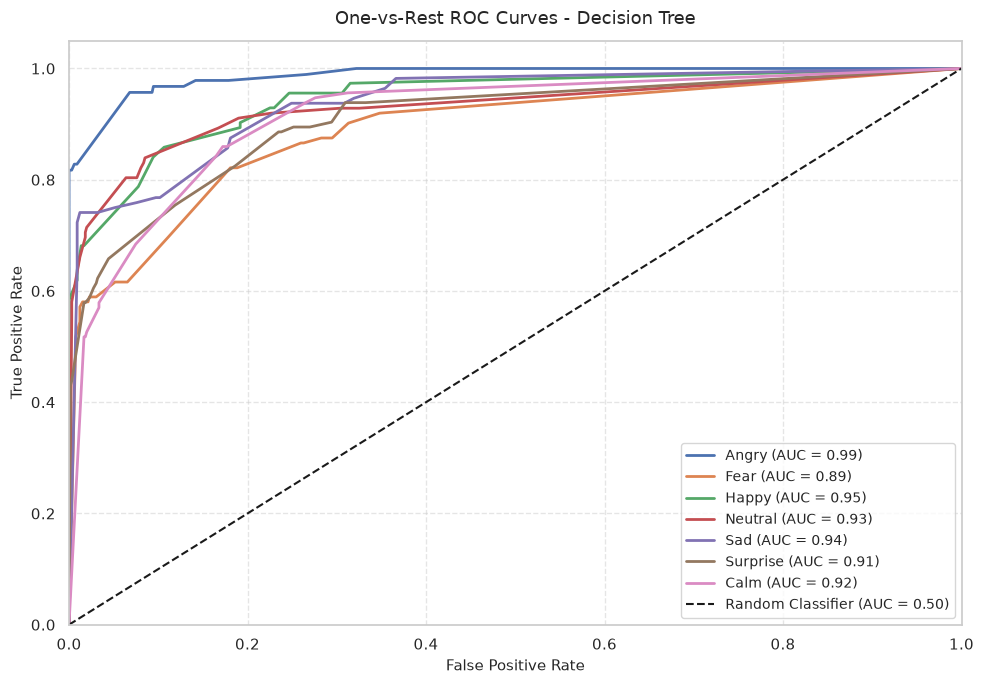

In [29]:
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# 1. Map labels safely using LabelEncoder 
# ---------------------------------------------------------
X = data[feature_columns]

# Automatically encode whatever unique labels exist in the CSV into contiguous 0 to N-1 integers
le = LabelEncoder()
y = le.fit_transform(data['label'])

# Define your 7 emotion names matching the encoded classes
emotion_names = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise', 'calm']
# (Note: LabelEncoder maps them in sorted order of your CSV's unique labels: [0, 2, 3, 4, 5, 6, 7])

# Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 2. Create & Train the Decision Tree Classifier
# ---------------------------------------------------------
model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 3. Make predictions and display Classification Report
# ---------------------------------------------------------
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    labels=list(range(len(emotion_names))),
    target_names=emotion_names,
    zero_division=0
))

# ---------------------------------------------------------
# 4. Display the Confusion Matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(emotion_names))))

fig, ax = plt.subplots(figsize=(8, 7))
ax.grid(False) # Turn off grid lines cutting through numbers

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_names)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=True)

plt.title('Decision Tree Confusion Matrix', fontsize=13, pad=12)
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Calculate and Plot Multiclass ROC-AUC 
# ---------------------------------------------------------
y_proba = model.predict_proba(X_test)

# Binarize true labels
all_classes = np.arange(len(emotion_names))
y_test_bin = label_binarize(y_test, classes=all_classes)

# Pad probabilities with zeros if a class was missing during training
if y_proba.shape[1] < len(all_classes):
    full_proba = np.zeros((len(y_test), len(all_classes)))
    for idx, class_id in enumerate(model.classes_):
        full_proba[:, class_id] = y_proba[:, idx]
    y_proba = full_proba

fig, ax = plt.subplots(figsize=(10, 7))
valid_aucs = []

# Plot curve for each emotion safely
for i, class_name in enumerate(emotion_names):
    if np.sum(y_test_bin[:, i]) == 0:
        print(f"Skipping '{class_name}' ROC - no samples in test set.")
        continue
        
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    class_auc = auc(fpr, tpr)
    valid_aucs.append(class_auc)
    
    ax.plot(
        fpr, tpr, lw=2,
        label=f'{class_name.capitalize()} (AUC = {class_auc:.2f})'
    )

if valid_aucs:
    safe_macro_auc = np.mean(valid_aucs)
    print(f"Safe Macro-average ROC-AUC Score: {safe_macro_auc:.4f}\n")

# Baseline line
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('One-vs-Rest ROC Curves - Decision Tree', fontsize=13, pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()